# 01 — CSP + LDA

Classical MI baseline. CSP learns spatial filters that maximise variance for one class and minimise it for the other (one-vs-rest for 3 classes); log-variance features go into an LDA.

Data-efficient and interpretable — the number to beat with any fancier model.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

from utils.data import load_xdf_epochs
from utils.eval import cv_score, summarise, save_result, RESULTS_DIR
from utils.plot import plot_confusion

X, y, classes = load_xdf_epochs('../visionpro-ml.xdf')
print('X:', X.shape, ' y:', y.shape, ' classes:', classes)

X: (90, 4, 625)  y: (90,)  classes: {0: 'left', 1: 'right', 2: 'both'}


In [2]:
def make_pipeline(n_components=4):
    # MNE CSP handles >2 classes via one-vs-rest internally.
    return Pipeline([
        ('csp', CSP(n_components=n_components, reg='ledoit_wolf',
                    log=True, norm_trace=False)),
        ('lda', LinearDiscriminantAnalysis()),
    ])

def fit_predict(X_tr, y_tr, X_val, y_val):
    pipe = make_pipeline(n_components=4)
    pipe.fit(X_tr, y_tr)
    return pipe.predict(X_val)

result = cv_score(fit_predict, X, y, n_splits=5, seed=42)
print(f"accuracy  : {result['accuracy']:.3f} ± {result['accuracy_std']:.3f}")
print(f"f1 macro  : {result['f1_macro']:.3f} ± {result['f1_macro_std']:.3f}")
print(f"per-class : {dict(zip(classes.values(), [round(v,3) for v in result['per_class_f1']]))}")

Computing rank from data with rank=None


    Using tolerance 0.26 (2.2e-16 eps * 4 dim * 2.9e+14  max singular value)


    Estimated rank (data): 4


    data: rank 4 computed from 4 data channels with 0 projectors


Reducing data rank from 4 -> 4


...

Estimating class=1 covariance using LEDOIT_WOLF


Done.


Estimating class=2 covariance using LEDOIT_WOLF


Done.


accuracy  : 0.344 ± 0.082
f1 macro  : 0.318 ± 0.062
per-class : {'left': 0.444, 'right': 0.221, 'both': 0.29}


### Quick sweep over `n_components`

With only 4 channels, `n_components` ≤ 4. We search to make sure 4 is best.

In [3]:
rows = []
for nc in (2, 3, 4):
    def _fp(X_tr, y_tr, X_val, y_val, nc=nc):
        pipe = make_pipeline(n_components=nc)
        pipe.fit(X_tr, y_tr)
        return pipe.predict(X_val)
    r = cv_score(_fp, X, y)
    rows.append({'n_components': nc, 'acc': r['accuracy'], 'f1': r['f1_macro']})
pd.DataFrame(rows)

Computing rank from data with rank=None


    Using tolerance 0.26 (2.2e-16 eps * 4 dim * 2.9e+14  max singular value)


    Estimated rank (data): 4


    data: rank 4 computed from 4 data channels with 0 projectors


Reducing data rank from 4 -> 4


...

Estimating class=1 covariance using LEDOIT_WOLF


Done.


Estimating class=2 covariance using LEDOIT_WOLF


Done.


,n_components,acc,f1
0,2,0.222222,0.210088
1,3,0.266667,0.256704
2,4,0.344444,0.318134


### Confusion matrix on the pooled CV predictions

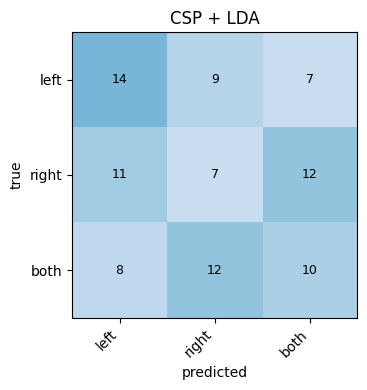

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_confusion(np.array(result['confusion']), classes, ax=ax, title='CSP + LDA')
plt.tight_layout(); plt.show()

### Save results and a final model fit on all data

In [5]:
save_result('01_csp_lda', result, classes)

final = make_pipeline(n_components=4)
final.fit(X, y)
joblib.dump({'pipeline': final, 'classes': classes}, RESULTS_DIR / '01_csp_lda.joblib')
print('saved results + joblib')

Computing rank from data with rank=None


    Using tolerance 0.29 (2.2e-16 eps * 4 dim * 3.3e+14  max singular value)


    Estimated rank (data): 4


    data: rank 4 computed from 4 data channels with 0 projectors


Reducing data rank from 4 -> 4


...

Estimating class=1 covariance using LEDOIT_WOLF


Done.


Estimating class=2 covariance using LEDOIT_WOLF


Done.


saved results + joblib
